### Load Train and Test from Kaggle

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

test = pd.read_csv("/content/test.csv")
print("Test shape:", test.shape )

train = pd.read_csv("/content/train.csv")
print("Train shape:",train.shape)
train.head()

Test shape: (3, 58)
Train shape: (28800, 60)


,ID,dri_score,psych_disturb,cyto_score,diabetes,hla_match_c_high,hla_high_res_8,tbi_status,arrhythmia,hla_low_res_6,graft_type,vent_hist,renal_issue,pulm_severe,prim_disease_hct,hla_high_res_6,cmv_status,hla_high_res_10,hla_match_dqb1_high,tce_imm_match,hla_nmdp_6,hla_match_c_low,rituximab,hla_match_drb1_low,hla_match_dqb1_low,prod_type,cyto_score_detail,conditioning_intensity,ethnicity,year_hct,obesity,mrd_hct,in_vivo_tcd,tce_match,hla_match_a_high,hepatic_severe,donor_age,prior_tumor,hla_match_b_low,peptic_ulcer,age_at_hct,hla_match_a_low,gvhd_proph,rheum_issue,sex_match,hla_match_b_high,race_group,comorbidity_score,karnofsky_score,hepatic_mild,tce_div_match,donor_related,melphalan_dose,hla_low_res_8,cardiac,hla_match_drb1_high,pulm_moderate,hla_low_res_10,efs,efs_time
0,0,N/A - non-malignant indication,No,NaN,No,NaN,NaN,No TBI,No,6.0,Bone marrow,No,No,No,IEA,6.0,+/+,NaN,2.0,NaN,6.0,2.0,No,2.0,2.0,BM,NaN,NaN,Not Hispanic or Latino,2016,No,NaN,Yes,NaN,2.0,No,NaN,No,2.0,No,9.942,2.0,FKalone,No,M-F,2.0,More than one race,0.0,90.0,No,NaN,Unrelated,"N/A, Mel not given",8.0,No,2.0,No,10.0,0.0,42.356
1,1,Intermediate,No,Intermediate,No,2.0,8.0,"TBI +- Other, >cGy",No,6.0,Peripheral blood,No,No,No,AML,6.0,+/+,10.0,2.0,P/P,6.0,2.0,No,2.0,2.0,PB,Intermediate,MAC,Not Hispanic or Latino,2008,No,Positive,No,Permissive,2.0,No,72.29,No,2.0,No,43.705,2.0,Other GVHD Prophylaxis,No,F-F,2.0,Asian,3.0,90.0,No,Permissive mismatched,Related,"N/A, Mel not given",8.0,No,2.0,Yes,10.0,1.0,4.672
2,2,N/A - non-malignant indication,No,NaN,No,2.0,8.0,No TBI,No,6.0,Bone marrow,No,No,No,HIS,6.0,+/+,10.0,2.0,P/P,6.0,2.0,No,2.0,2.0,BM,NaN,NaN,Not Hispanic or Latino,2019,No,NaN,Yes,NaN,2.0,No,NaN,No,2.0,No,33.997,2.0,Cyclophosphamide alone,No,F-M,2.0,More than one race,0.0,90.0,No,Permissive mismatched,Related,"N/A, Mel not given",8.0,No,2.0,No,10.0,0.0,19.793
3,3,High,No,Intermediate,No,2.0,8.0,No TBI,No,6.0,Bone marrow,No,No,No,ALL,6.0,+/+,10.0,2.0,P/P,6.0,2.0,No,2.0,2.0,BM,Intermediate,MAC,Not Hispanic or Latino,2009,No,Positive,No,Permissive,2.0,No,29.23,No,2.0,No,43.245,2.0,FK+ MMF +- others,No,M-M,2.0,White,0.0,90.0,Yes,Permissive mismatched,Unrelated,"N/A, Mel not given",8.0,No,2.0,No,10.0,0.0,102.349
4,4,High,No,NaN,No,2.0,8.0,No TBI,No,6.0,Peripheral blood,No,No,No,MPN,6.0,+/+,10.0,2.0,NaN,5.0,2.0,No,2.0,2.0,PB,NaN,MAC,Hispanic or Latino,2018,No,NaN,Yes,NaN,2.0,No,56.81,No,2.0,No,29.740,2.0,TDEPLETION +- other,No,M-F,2.0,American Indian or Alaska Native,1.0,90.0,No,Permissive mismatched,Related,MEL,8.0,No,2.0,No,10.0,0.0,16.223


### Feature engineering

Just Label encoding here

In [ ]:
remove = ["ID","efs","efs_time","y"]
FEATURES = [c for c in train.columns if not c in remove]
print(f"There are {len(FEATURES)} FEATURES: {FEATURES}")

There are 57 FEATURES: ['dri_score', 'psych_disturb', 'cyto_score', 'diabetes', 'hla_match_c_high', 'hla_high_res_8', 'tbi_status', 'arrhythmia', 'hla_low_res_6', 'graft_type', 'vent_hist', 'renal_issue', 'pulm_severe', 'prim_disease_hct', 'hla_high_res_6', 'cmv_status', 'hla_high_res_10', 'hla_match_dqb1_high', 'tce_imm_match', 'hla_nmdp_6', 'hla_match_c_low', 'rituximab', 'hla_match_drb1_low', 'hla_match_dqb1_low', 'prod_type', 'cyto_score_detail', 'conditioning_intensity', 'ethnicity', 'year_hct', 'obesity', 'mrd_hct', 'in_vivo_tcd', 'tce_match', 'hla_match_a_high', 'hepatic_severe', 'donor_age', 'prior_tumor', 'hla_match_b_low', 'peptic_ulcer', 'age_at_hct', 'hla_match_a_low', 'gvhd_proph', 'rheum_issue', 'sex_match', 'hla_match_b_high', 'race_group', 'comorbidity_score', 'karnofsky_score', 'hepatic_mild', 'tce_div_match', 'donor_related', 'melphalan_dose', 'hla_low_res_8', 'cardiac', 'hla_match_drb1_high', 'pulm_moderate', 'hla_low_res_10']


In [ ]:
CATS = []
for c in FEATURES:
    if train[c].dtype=="object":
        CATS.append(c)
        train[c] = train[c].fillna("NAN")
        test[c] = test[c].fillna("NAN")
print(f"In these features, there are {len(CATS)} CATEGORICAL FEATURES: {CATS}")

In these features, there are 35 CATEGORICAL FEATURES: ['dri_score', 'psych_disturb', 'cyto_score', 'diabetes', 'tbi_status', 'arrhythmia', 'graft_type', 'vent_hist', 'renal_issue', 'pulm_severe', 'prim_disease_hct', 'cmv_status', 'tce_imm_match', 'rituximab', 'prod_type', 'cyto_score_detail', 'conditioning_intensity', 'ethnicity', 'obesity', 'mrd_hct', 'in_vivo_tcd', 'tce_match', 'hepatic_severe', 'prior_tumor', 'peptic_ulcer', 'gvhd_proph', 'rheum_issue', 'sex_match', 'race_group', 'hepatic_mild', 'tce_div_match', 'donor_related', 'melphalan_dose', 'cardiac', 'pulm_moderate']


### Kaplan Meier

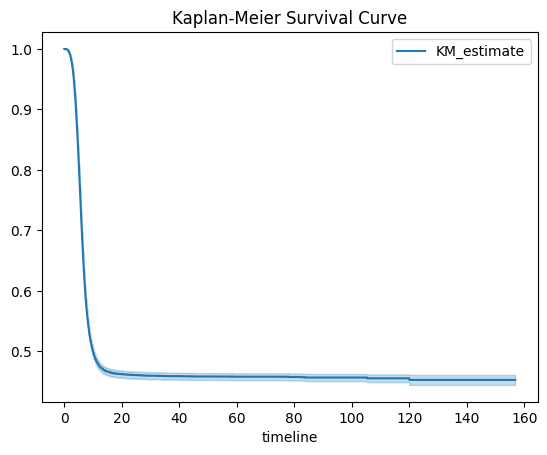

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Fit Kaplan-Meier estimator
kmf = KaplanMeierFitter()

# Plot Kaplan-Meier curves for the whole dataset
kmf.fit(durations=train['efs_time'], event_observed=train['efs'])
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.show()

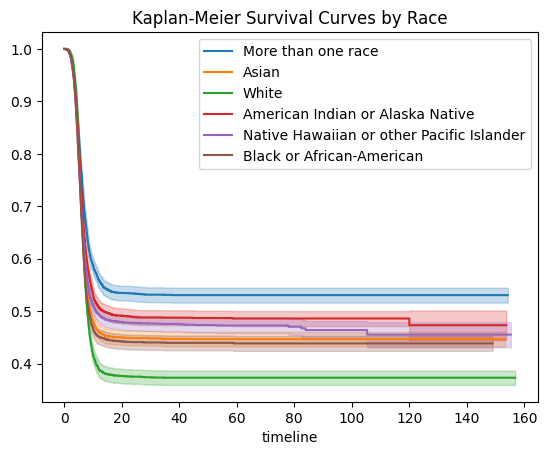

In [ ]:
# Plot Kaplan-Meier curves by groups
kmf = KaplanMeierFitter()
for group in train['race_group'].unique():
    group_data = train[train['race_group'] == group]
    kmf.fit(durations=group_data['efs_time'], event_observed=group_data['efs'], label=str(group))
    kmf.plot_survival_function()

plt.title('Kaplan-Meier Survival Curves by Race')
plt.show()


### XGBoost

In [ ]:
!pip install xgboost
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 4.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=5853226635790ff2aa6feb2eed2a88a552eefd7105837c37721407b31fb2a23b
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
import xgboost as xgb
from lifelines.utils import concordance_index

# Load data
train = pd.read_csv('/content/train.csv')

# Preprocess missing values
train.replace(['N/A', '', ' ', 'Not done', 'Not tested', 'N/A - non-malignant indication',
               'N/A - pediatric', 'N/A - disease not classifiable'], np.nan, inplace=True)

# Extract targets and race groups
y_time = train['efs_time']
y_event = train['efs']
race_groups = train['race_group']

# Drop non-feature columns
X = train.drop(['efs', 'efs_time', 'ID'], axis=1)

# Identify categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# ----------------------
# Remove Low-Variance Features
# ----------------------
# Encode categorical features temporarily for variance calculation
X_encoded = X.copy()
for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))

# Remove low-variance features
selector = VarianceThreshold(threshold=0.01)  # Adjust threshold if needed
X_reduced = selector.fit_transform(X_encoded)

# Get selected feature indices and update original X
selected_features = selector.get_support(indices=True)
X = X.iloc[:, selected_features]

# Update categorical columns list based on reduced features
cat_cols = [col for col in cat_cols if col in X.columns]

# ----------------------
# Train-Test Split
# ----------------------
# Split data (stratified by race) using reduced features
X_train, X_val, y_time_train, y_time_val, y_event_train, y_event_val, race_train, race_val = train_test_split(
    X, y_time, y_event, race_groups, test_size=0.2, stratify=race_groups, random_state=42
)

# ----------------------
# XGBoost AFT Model
# ----------------------
# Label encode categorical features for XGBoost
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train[col].astype(str))
    X_val_encoded[col] = le.transform(X_val[col].astype(str))
    label_encoders[col] = le

# Prepare AFT bounds
lower_train = y_time_train.copy()
upper_train = y_time_train.copy()
upper_train[y_event_train == 0] = np.inf

dtrain = xgb.DMatrix(X_train_encoded, label_lower_bound=lower_train, label_upper_bound=upper_train)
dval = xgb.DMatrix(X_val_encoded)

params = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'aft_loss_distribution_scale': 1.0,
    'tree_method': 'hist',
    'learning_rate': 0.05,
    'max_depth': 8,
}

model_xgb = xgb.train(params, dtrain, num_boost_round=300)
pred_time_xgb = model_xgb.predict(dval)
risk_xgb = 1 / pred_time_xgb

# ----------------------
# Stratified C-index Calculation
# ----------------------
def stratified_c_index(y_true, pred_risk, groups, y_event):
    unique_groups = groups.unique()
    c_indices = []
    for group in unique_groups:
        mask = groups == group
        if sum(mask) < 2:
            continue  # Skip groups with <2 samples
        c = concordance_index(y_true[mask], -pred_risk[mask], y_event[mask])
        c_indices.append(c)
    return np.nanmean(c_indices)

# Calculate performance
c_xgb = stratified_c_index(y_time_val, risk_xgb, race_val, y_event_val)

print(f"XGBoost Stratified C-index: {c_xgb:.4f}")


XGBoost Stratified C-index: 0.6595


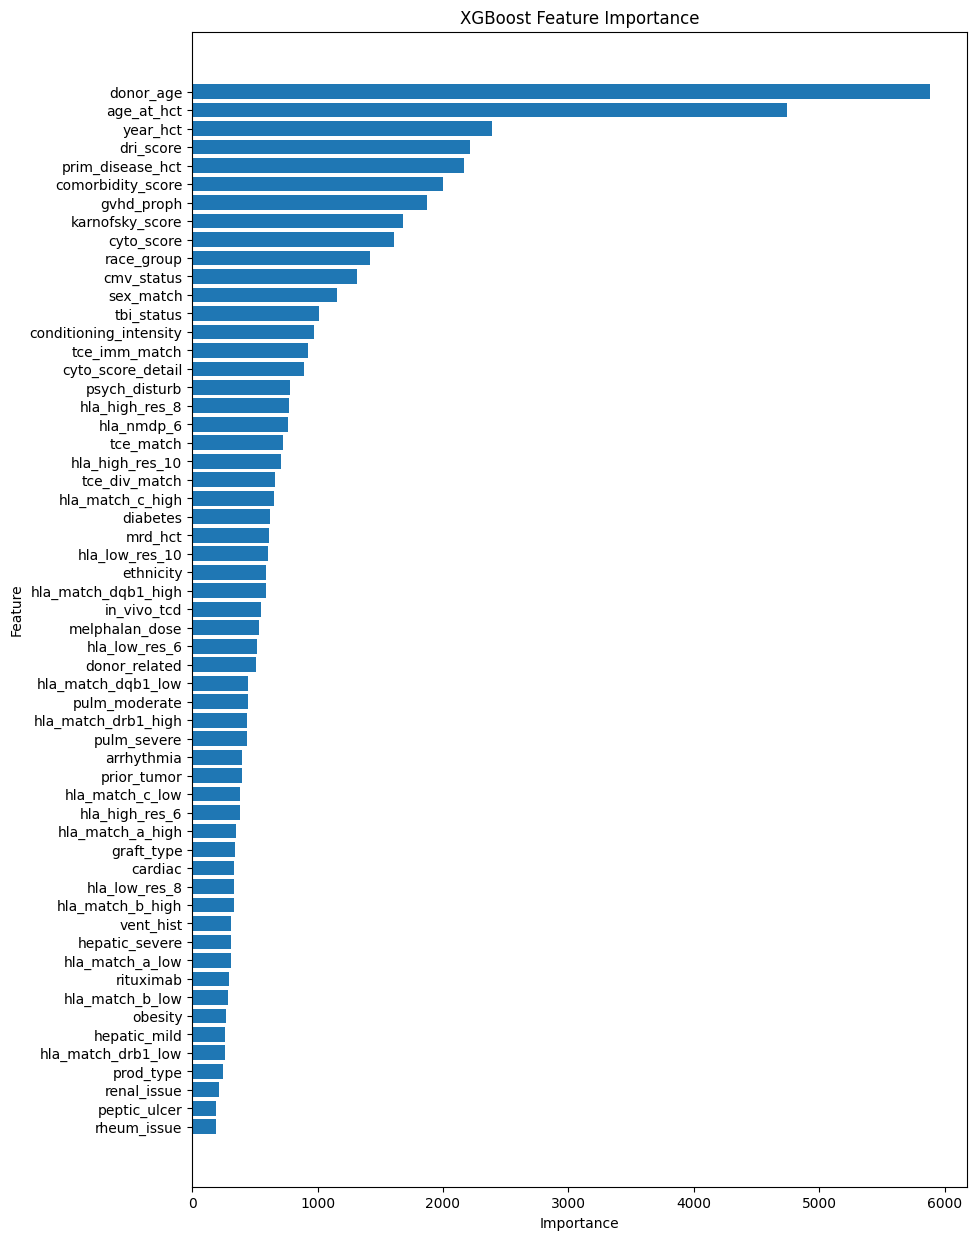

In [ ]:
# ----------------------
# Feature Importance Extraction
# ----------------------
# Get feature importances from the trained model
feature_importance = model_xgb.get_score(importance_type='weight')  # 'weight' counts how many times a feature is used in a split

# Sort features by importance
importance_df = pd.DataFrame({
    "Feature": list(feature_importance.keys()),
    "Importance": list(feature_importance.values())
}).sort_values(by="Importance", ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 15))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
##----------- Just trying something--------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import xgboost as xgb
from lifelines.utils import concordance_index

# Load data
train = pd.read_csv('features.csv')

# Clean column names
def sanitize_feature_names(df):
    df.columns = [str(col).replace('[', '').replace(']', '').replace('<', '').replace(' ', '_')
                  for col in df.columns]
    return df

# Apply to your DataFrame after loading
train = sanitize_feature_names(train)

# Then continue with your existing processing...
train = pd.read_csv('features.csv')
train = sanitize_feature_names(train)

# Convert True/False strings to 1/0
for col in train.columns:
    if train[col].dtype == 'object':
        unique_vals = train[col].unique()
        if set(unique_vals) <= {'True', 'False'}:
            train[col] = train[col].map({'True': 1, 'False': 0}).astype(int)

# Handle missing values (represented by -1/-1.0)
train.replace([-1, -1.0], np.nan, inplace=True)

# Create race_group column from one-hot encoded columns
race_columns = [col for col in train.columns if col.startswith('race_group_')]
train['race_group'] = train[race_columns].idxmax(axis=1).str.replace('race_group_', '')

# Extract targets and race groups
y_time = train['efs_time']
y_event = train['efs']
race_groups = train['race_group']

# Drop non-feature columns including original race columns
X = train.drop(columns=['efs', 'efs_time', 'ID', 'race_group'] + race_columns)

# ----------------------
# Remove Low-Variance Features
# ----------------------
selector = VarianceThreshold(threshold=0.01)
X_reduced = selector.fit_transform(X)

# Get selected features
selected_features = selector.get_support(indices=True)
X = X.iloc[:, selected_features]

# ----------------------
# Train-Test Split (stratified by race_group)
# ----------------------
X_train, X_val, y_time_train, y_time_val, y_event_train, y_event_val, race_train, race_val = train_test_split(
    X, y_time, y_event, race_groups,
    test_size=0.2, stratify=race_groups, random_state=42
)

# ----------------------
# XGBoost AFT Model
# ----------------------
# Prepare AFT bounds
lower_bound = y_time_train.values.copy()
upper_bound = np.where(y_event_train == 1, y_time_train, np.inf)

dtrain = xgb.DMatrix(X_train, label_lower_bound=lower_bound, label_upper_bound=upper_bound)
dval = xgb.DMatrix(X_val)

params = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'aft_loss_distribution_scale': 1.0,
    'tree_method': 'hist',
    'learning_rate': 0.05,
    'max_depth': 8,
}

model_xgb = xgb.train(params, dtrain, num_boost_round=300)
pred_time_xgb = model_xgb.predict(dval)
risk_xgb = 1 / pred_time_xgb  # Convert predicted time to risk score

# ----------------------
# Stratified C-index Calculation
# ----------------------
def stratified_c_index(y_true, pred_risk, groups, y_event):
    unique_groups = groups.unique()
    c_indices = []
    for group in unique_groups:
        mask = groups == group
        if sum(mask) < 2: continue
        c = concordance_index(y_true[mask], -pred_risk[mask], y_event[mask])
        c_indices.append(c)
    return np.nanmean(c_indices)

c_xgb = stratified_c_index(y_time_val, risk_xgb, race_val, y_event_val)
print(f"XGBoost Stratified C-index: {c_xgb:.4f}")

XGBoost Stratified C-index: 0.6582


COX model

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

In [ ]:
import pandas as pd
from lifelines.utils import concordance_index

# Load data
train_df = pd.read_csv('/content/features.csv')

# Drop irrelevant column
train_df = train_df.drop('gvhd_proph_FK+- others(not MMF,MTX)', axis=1)

# Check for missing values
print("Missing values in train_df:")
print(train_df.isnull().sum())

# Handle missing values (drop or impute)
train_df = train_df.fillna(train_df.median())

# Ensure required columns exist
assert 'efs_time' in train_df.columns, "Column 'efs_time' not found in dataset"
assert 'efs' in train_df.columns, "Column 'efs' not found in dataset"

# Instantiate the CoxPHFitter with regularization
cph = CoxPHFitter(penalizer=0.5, l1_ratio=0.5)  # Adjust penalizer and l1_ratio as needed

# Fit the model
cph.fit(train_df, duration_col='efs_time', event_col='efs')

# Print the summary
cph.print_summary()

# Check proportional hazards assumption
cph.check_assumptions(train_df, p_value_threshold=0.05)

# ----------------------
# Calculate C-index
# ----------------------
# Get predicted risk scores from the Cox model
risk_scores = cph.predict_partial_hazard(train_df)

# Calculate the C-index
c_index = concordance_index(
    event_times=train_df['efs_time'],  # Actual survival times
    predicted_scores=risk_scores,      # Predicted risk scores
    event_observed=train_df['efs']     # Event indicators (1 if event occurred, 0 if censored)
)

print(f"C-index: {c_index:.4f}")

Missing values in train_df:
ID                                         0
dri_score                                  0
psych_disturb                              0
cyto_score                                 0
diabetes                                   0
                                          ..
gvhd_proph_No GvHD Prophylaxis             0
gvhd_proph_Other GVHD Prophylaxis          0
gvhd_proph_Parent Q = yes, but no agent    0
gvhd_proph_TDEPLETION +- other             0
gvhd_proph_TDEPLETION alone                0
Length: 131, dtype: int64


<lifelines.CoxPHFitter: fitted with 28800 total observations, 13268 right-censored observations>
             duration col = 'efs_time'
                event col = 'efs'
                penalizer = 0.5
                 l1 ratio = 0.5
      baseline estimation = breslow
   number of observations = 28800
number of events observed = 15532
   partial log-likelihood = -154145.62
         time fit was run = 2025-03-05 03:06:43 UTC

---
                                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                             
ID                                                   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
dri_score                                             0.00      1.00      0.00           -0.00            0.00                1.00                1.00
psych_disturb                                         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cyto_score                                           -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
diabetes                                              0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_match_c_high                                      0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_high_res_8                                        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
arrhythmia                                            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_low_res_6                                         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
graft_type                                            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
vent_hist                                            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
renal_issue                                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
pulm_severe                                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_high_res_6                                        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
cmv_status                                            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_high_res_10                                       0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_match_dqb1_high                                   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_nmdp_6                                            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_match_c_low                                       0.00      1.00      0.00           -0.00            0.00                1.00                1.00
rituximab                                            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_match_drb1_low                                    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
hla_match_dqb1_low                                    0.00      1.00      0.00           -0.0

Proportional hazard assumption looks okay.
C-index: 0.3768


## Ensemble Cox and xgboost

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# Load data
train = pd.read_csv('features.csv')

# Clean column names
def sanitize_feature_names(df):
    df.columns = [str(col).replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in df.columns]
    return df

train = sanitize_feature_names(train)

# Convert True/False strings to 1/0
for col in train.columns:
    if train[col].dtype == 'object':
        unique_vals = train[col].unique()
        if set(unique_vals) <= {'True', 'False'}:
            train[col] = train[col].map({'True': 1, 'False': 0}).astype(int)

# Handle missing values (represented by -1/-1.0)
train.replace([-1, -1.0], np.nan, inplace=True)

# Create race_group column from one-hot encoded columns
race_columns = [col for col in train.columns if col.startswith('race_group_')]
train['race_group'] = train[race_columns].idxmax(axis=1).str.replace('race_group_', '')

# Extract targets and race groups
y_time = train['efs_time']
y_event = train['efs']
race_groups = train['race_group']

# Drop non-feature columns including original race columns
X = train.drop(columns=['efs', 'efs_time', 'ID', 'race_group'] + race_columns)

# ----------------------
# Preprocessing: Remove Low-Variance Features
# ----------------------
selector = VarianceThreshold(threshold=0.05)
X_reduced = selector.fit_transform(X)

# Get selected features
selected_features = selector.get_support(indices=True)
X = X.iloc[:, selected_features]

# Train-Test Split (stratified by race_group)
X_train, X_val, y_time_train, y_time_val, y_event_train, y_event_val, race_train, race_val = train_test_split(
    X, y_time, y_event, race_groups,
    test_size=0.2, stratify=race_groups, random_state=42
)

# ----------------------
# XGBoost AFT Model
# ----------------------
# Prepare AFT bounds for XGBoost
lower_bound = y_time_train.values.copy()
upper_bound = np.where(y_event_train == 1, y_time_train, np.inf)

dtrain = xgb.DMatrix(X_train, label_lower_bound=lower_bound, label_upper_bound=upper_bound)
dval = xgb.DMatrix(X_val)

params = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'aft_loss_distribution_scale': 1.0,
    'tree_method': 'hist',
    'learning_rate': 0.05,
    'max_depth': 8,
}

model_xgb = xgb.train(params, dtrain, num_boost_round=100)
pred_time_xgb = model_xgb.predict(dval)
risk_xgb = 1 / pred_time_xgb  # Convert predicted time to risk score

# ----------------------
# Cox Proportional Hazards Model
# ----------------------
# Ensure no missing values in train_df for Cox model
train_cleaned = train.dropna(subset=['efs_time', 'efs'])

# Separate numeric and categorical columns
numeric_columns = train_cleaned.select_dtypes(include=[np.number]).columns
categorical_columns = train_cleaned.select_dtypes(exclude=[np.number]).columns

# Impute missing values for numeric columns using median
train_cleaned[numeric_columns] = train_cleaned[numeric_columns].fillna(train_cleaned[numeric_columns].median())

# Drop non-numerical columns (for Cox model fitting)
train_cleaned = train_cleaned.drop(columns=['ID', 'race_group'] + race_columns)

cph = CoxPHFitter(penalizer=0.5, l1_ratio=0.5)
cph.fit(train_cleaned, duration_col='efs_time', event_col='efs')

# Get predicted risk scores from the Cox model
risk_cox = cph.predict_partial_hazard(train_cleaned)



In [ ]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split

# Load and prepare data
train = pd.read_csv('features.csv')
train = train.drop('gvhd_proph_FK+- others(not MMF,MTX)', axis=1)
train = train.dropna()  # Handle missing values

# Ensure required columns exist
assert 'efs_time' in train.columns, "Column 'efs_time' not found in dataset"
assert 'efs' in train.columns, "Column 'efs' not found in dataset"

# Train-test split
X_train, X_val, y_time_train, y_time_val, y_event_train, y_event_val = train_test_split(
    train.drop(columns=['efs', 'efs_time']), train['efs_time'], train['efs'], test_size=0.2, random_state=42
)

# Define a range of penalizer values to test
penalizer_values = [0.01, 0.1, 0.5, 1.0, 2.0]

# Store results
results = []

# Iterate over penalizer values
for penalizer in penalizer_values:
    # Fit Cox model
    cph = CoxPHFitter(penalizer=penalizer, l1_ratio=0.5)
    cph.fit(pd.concat([X_train, y_time_train, y_event_train], axis=1), duration_col='efs_time', event_col='efs')

    # Predict risk scores on validation set
    risk_scores = cph.predict_partial_hazard(X_val)

    # Calculate C-index
    c_index = concordance_index(y_time_val, risk_scores, y_event_val)

    # Store results
    results.append((penalizer, c_index))
    print(f"Penalizer: {penalizer}, C-index: {c_index:.4f}")

# Find the best penalizer
best_penalizer, best_c_index = max(results, key=lambda x: x[1])
print(f"Best penalizer: {best_penalizer}, Best C-index: {best_c_index:.4f}")

Penalizer: 0.01, C-index: 0.3452
Penalizer: 0.1, C-index: 0.3661
Penalizer: 0.5, C-index: 0.3768
Penalizer: 1.0, C-index: 0.3772
Penalizer: 2.0, C-index: 0.3773
Best penalizer: 2.0, Best C-index: 0.3773


In [ ]:
# ----------------------
# Ensure the same preprocessing is done for the validation set for Cox model
# ----------------------
# Prepare the validation set in the same way
X_val_cleaned = X_val.copy()

# Add 'efs_time' and 'efs' to the validation set
X_val_cleaned['efs_time'] = y_time_val
X_val_cleaned['efs'] = y_event_val

# Get the exact columns that were used in the training set (train_cleaned.columns)
expected_columns = train_cleaned.columns

# Ensure the validation set has exactly the same columns as the training set
# Add missing columns with zeros or NaNs, and drop extra columns
for col in expected_columns:
    if col not in X_val_cleaned.columns:
        X_val_cleaned[col] = 0  # or np.nan, depending on how you handled missing data in training

X_val_cleaned = X_val_cleaned[expected_columns]

# Impute missing values in the validation set for Cox model if necessary
X_val_cleaned = X_val_cleaned.fillna(X_val_cleaned.median())

# Get predicted risk scores from the Cox model for the validation set
risk_cox_val = cph.predict_partial_hazard(X_val_cleaned)

# ----------------------
# Ensemble the Models
# ----------------------
# Weight the models based on performance, or equally if unknown. Here, we assume equal weights.
weight_xgb = 0.7
weight_cox = 0.3

# Ensemble the risk scores
ensemble_risk = weight_xgb * risk_xgb + weight_cox * risk_cox_val

# ----------------------
# Stratified C-index Calculation for Ensemble
# ----------------------
def stratified_c_index(y_true, pred_risk, groups, y_event):
    unique_groups = groups.unique()
    c_indices = []
    for group in unique_groups:
        mask = groups == group
        if sum(mask) < 2: continue
        c = concordance_index(y_true[mask], -pred_risk[mask], y_event[mask])
        c_indices.append(c)
    return np.nanmean(c_indices)

c_ensemble = stratified_c_index(y_time_val, ensemble_risk, race_val, y_event_val)
print(f"Ensemble Stratified C-index: {c_ensemble:.3f}")


Ensemble Stratified C-index: 0.6565


### Retraining based on important features- XGboost

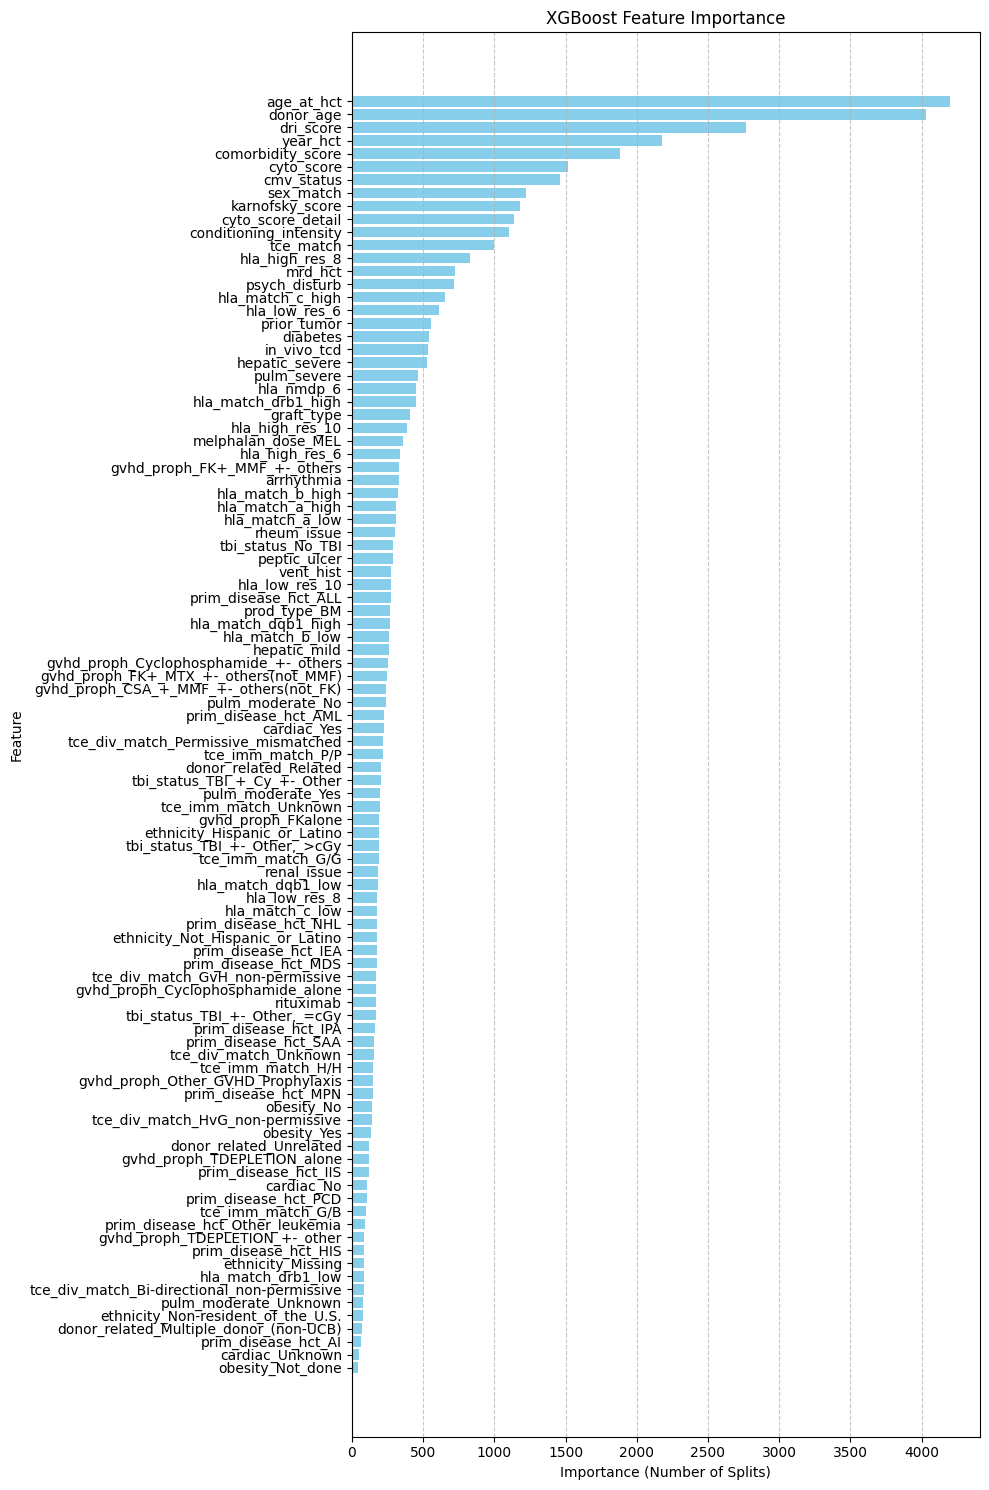

In [ ]:
import matplotlib.pyplot as plt

# ----------------------
# Feature Importance Extraction
# ----------------------
# Get feature importances from the trained model
feature_importance = model_xgb.get_score(importance_type='weight')  # 'weight' counts how many times a feature is used in a split

# Sort features by importance
importance_df = pd.DataFrame({
    "Feature": list(feature_importance.keys()),
    "Importance": list(feature_importance.values())
}).sort_values(by="Importance", ascending=False)

# Plot the feature importance
plt.figure(figsize=(10, 15))
plt.barh(importance_df["Feature"], importance_df["Importance"], color='skyblue')
plt.xlabel("Importance (Number of Splits)")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()  # Flip features for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add gridlines for better readability
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()

In [ ]:
top_n = 20  # Plot top 20 features
importance_df = importance_df.head(top_n)
print(f"Top {top_n} Features:")
print(importance_df)

Top 20 Features:
                   Feature  Importance
33              age_at_hct      4199.0
29               donor_age      4030.0
0                dri_score      2767.0
23                year_hct      2178.0
38       comorbidity_score      1884.0
2               cyto_score      1517.0
13              cmv_status      1459.0
36               sex_match      1223.0
39         karnofsky_score      1179.0
21       cyto_score_detail      1135.0
22  conditioning_intensity      1103.0
26               tce_match       995.0
5           hla_high_res_8       832.0
24                 mrd_hct       726.0
1            psych_disturb       719.0
4         hla_match_c_high       653.0
7            hla_low_res_6       613.0
30             prior_tumor       556.0
3                 diabetes       544.0
25             in_vivo_tcd       537.0


In [ ]:
# Example: Keep top 20 features
top_n = 20
selected_features = importance_df["Feature"].head(top_n).tolist()

# Example: Keep features contributing to 95% of total importance
cumulative_importance = importance_df["Importance"].cumsum() / importance_df["Importance"].sum()
selected_features = importance_df[cumulative_importance <= 0.95]["Feature"].tolist()

# Filter the dataset
X_train_reduced = X_train[selected_features]
X_val_reduced = X_val[selected_features]

In [ ]:
# Prepare AFT bounds for reduced dataset
lower_bound = y_time_train.values.copy()
upper_bound = np.where(y_event_train == 1, y_time_train, np.inf)

# Create DMatrix for reduced dataset
dtrain_reduced = xgb.DMatrix(X_train_reduced, label_lower_bound=lower_bound, label_upper_bound=upper_bound)
dval_reduced = xgb.DMatrix(X_val_reduced)

# Retrain the model
model_xgb_reduced = xgb.train(params, dtrain_reduced, num_boost_round=100)

# Evaluate the model
pred_time_xgb_reduced = model_xgb_reduced.predict(dval_reduced)
risk_xgb_reduced = 1 / pred_time_xgb_reduced

# Calculate stratified C-index
c_xgb_reduced = stratified_c_index(y_time_val, risk_xgb_reduced, race_val, y_event_val)
print(f"Reduced Model Stratified C-index: {c_xgb_reduced:.4f}")

Reduced Model Stratified C-index: 0.6500


### CatBoost

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from catboost import CatBoostRegressor
from lifelines.utils import concordance_index
from collections import Counter

# Load data
train = pd.read_csv('/content/train.csv')

# Preprocess missing values
train.replace(['N/A', '', ' ', 'Not done', 'Not tested', 'N/A - non-malignant indication',
               'N/A - pediatric', 'N/A - disease not classifiable'], np.nan, inplace=True)

# Extract targets and race groups
y_time = train['efs_time']
y_event = train['efs']
race_groups = train['race_group']

# Drop non-feature columns
X = train.drop(['efs', 'efs_time', 'ID'], axis=1)

# Identify categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# ----------------------
# Remove Low-Variance Features
# ----------------------
# Encode categorical features temporarily for variance calculation
X_encoded = X.copy()
for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))

# Remove low-variance features
selector = VarianceThreshold(threshold=0.01)  # Adjust threshold if needed
X_reduced = selector.fit_transform(X_encoded)

# Get selected feature indices and update original X
selected_features = selector.get_support(indices=True)
X = X.iloc[:, selected_features]

# Update categorical columns list based on reduced features
cat_cols = [col for col in cat_cols if col in X.columns]

# ----------------------
# Train-Test Split
# ----------------------
# Split data (stratified by race) using reduced features
X_train, X_val, y_time_train, y_time_val, y_event_train, y_event_val, race_train, race_val = train_test_split(
    X, y_time, y_event, race_groups, test_size=0.2, stratify=race_groups, random_state=42
)

print("\nTraining CatBoost Model...")

# Replace NaN in categorical columns with a string
X_train[cat_cols] = X_train[cat_cols].fillna("missing")
X_val[cat_cols] = X_val[cat_cols].fillna("missing")

# Find categorical column indices for CatBoost
cat_col_indices = [X.columns.get_loc(col) for col in cat_cols]

# Train CatBoost Regressor for survival analysis
model_cb = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    cat_features=cat_col_indices,
    loss_function='MAE',  # CatBoost doesn't support AFT directly, using MAE as a proxy
    verbose=50
)
model_cb.fit(X_train, y_time_train)

# Predict risk score for validation set
pred_time_cb = model_cb.predict(X_val)
risk_cb = 1 / pred_time_cb  # Risk score = inverse of predicted time

# Calculate performance for CatBoost
c_cb = stratified_c_index(y_time_val, risk_cb, race_val, y_event_val)
print(f"CatBoost Stratified C-index: {c_cb:.4f}")


Training CatBoost Model...
0:	learn: 17.4494580	total: 350ms	remaining: 1m 44s
50:	learn: 15.0651343	total: 14s	remaining: 1m 8s
100:	learn: 14.5673687	total: 28.5s	remaining: 56.2s
150:	learn: 14.2983629	total: 41.9s	remaining: 41.4s
200:	learn: 14.0978770	total: 55.7s	remaining: 27.5s
250:	learn: 13.8846500	total: 1m 10s	remaining: 13.7s
299:	learn: 13.7046177	total: 1m 26s	remaining: 0us
CatBoost Stratified C-index: 0.6521


### Ensemble

In [ ]:
# ----------------------
# Ensemble Risk Score
# ----------------------
print("\nCalculating Ensemble Risk Score...")

# Simple average ensemble of risk scores
risk_ensemble = (risk_xgb + risk_cb) / 2

c_ensemble = stratified_c_index(y_time_val, risk_ensemble, race_val, y_event_val)
print(f"Ensemble Stratified C-index: {c_ensemble:.4f}")



Calculating Ensemble Risk Score...
Ensemble Stratified C-index: 0.6619


## Kaplan Meier + XgBoost + Cox

In [ ]:
from lifelines import KaplanMeierFitter

# Function to calculate survival probabilities using Kaplan-Meier
def transform_survival_probability(df, time_col='efs_time', event_col='efs'):
    kmf = KaplanMeierFitter()
    kmf.fit(df[time_col], df[event_col])
    y = kmf.survival_function_at_times(df[time_col]).values
    return y

# Apply the function to calculate survival probability and assign it to the 'y' column
train["y"] = transform_survival_probability(train, time_col='efs_time', event_col='efs')

# Drop the original 'efs' and 'efs_time' columns as they are now transformed into 'y'
train = train.drop(columns=['efs', 'efs_time'])


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index

# Load data
train = pd.read_csv('features.csv')

# Clean column names
def sanitize_feature_names(df):
    df.columns = [str(col).replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in df.columns]
    return df

train = sanitize_feature_names(train)

# Convert True/False strings to 1/0
for col in train.columns:
    if train[col].dtype == 'object':
        unique_vals = train[col].unique()
        if set(unique_vals) <= {'True', 'False'}:
            train[col] = train[col].map({'True': 1, 'False': 0}).astype(int)

# Handle missing values (represented by -1/-1.0)
train.replace([-1, -1.0], np.nan, inplace=True)

# Create race_group column from one-hot encoded columns
race_columns = [col for col in train.columns if col.startswith('race_group_')]
train['race_group'] = train[race_columns].idxmax(axis=1).str.replace('race_group_', '')

# Extract targets and race groups
y_time = train['efs_time']
y_event = train['efs']
race_groups = train['race_group']

# Drop non-feature columns including original race columns
X = train.drop(columns=['efs', 'efs_time', 'ID', 'race_group'] + race_columns)

# ----------------------
# Kaplan-Meier Transformation to Calculate Survival Probabilities
# ----------------------
def transform_survival_probability(df, time_col='efs_time', event_col='efs'):
    kmf = KaplanMeierFitter()
    kmf.fit(df[time_col], df[event_col])
    y = kmf.survival_function_at_times(df[time_col]).values
    return y

# Calculate Kaplan-Meier survival probabilities for the training data
train["y"] = transform_survival_probability(train, time_col='efs_time', event_col='efs')

# Drop the columns used for target variable calculation (efs_time, efs)
train_cleaned = train.drop(columns=['efs_time', 'efs'])

# ----------------------
# Preprocessing: Remove Low-Variance Features
# ----------------------
selector = VarianceThreshold(threshold=0.05)
X_reduced = selector.fit_transform(X)

# Get selected features
selected_features = selector.get_support(indices=True)
X = X.iloc[:, selected_features]

# Train-Test Split (stratified by race_group)
X_train, X_val, y_time_train, y_time_val, y_event_train, y_event_val, race_train, race_val = train_test_split(
    X, y_time, y_event, race_groups,
    test_size=0.2, stratify=race_groups, random_state=42
)

# ----------------------
# XGBoost AFT Model
# ----------------------
# Prepare AFT bounds for XGBoost
lower_bound = y_time_train.values.copy()
upper_bound = np.where(y_event_train == 1, y_time_train, np.inf)

dtrain = xgb.DMatrix(X_train, label_lower_bound=lower_bound, label_upper_bound=upper_bound)
dval = xgb.DMatrix(X_val)

params = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'aft_loss_distribution_scale': 1.0,
    'tree_method': 'hist',
    'learning_rate': 0.05,
    'max_depth': 8,
}

model_xgb = xgb.train(params, dtrain, num_boost_round=300)
pred_time_xgb = model_xgb.predict(dval)
risk_xgb = 1 / pred_time_xgb  # Convert predicted time to risk score

# Stratified C-index for XGBoost
c_xgb = stratified_c_index(y_time_val, risk_xgb, race_val, y_event_val)
print(f"XGBoost Stratified C-index: {c_xgb:.3f}")


XGBoost Stratified C-index: 0.660


In [1]:
# ----------------------
# Cox Proportional Hazards Model
# ----------------------
# Ensure no missing values in train_cleaned for Cox model
train_cleaned = train.dropna(subset=['y'])  # We only need to drop rows with missing 'y' after calculating Kaplan-Meier survival

# Separate numeric and categorical columns
numeric_columns = train_cleaned.select_dtypes(include=[np.number]).columns
categorical_columns = train_cleaned.select_dtypes(exclude=[np.number]).columns

# Impute missing values for numeric columns using median
train_cleaned[numeric_columns] = train_cleaned[numeric_columns].fillna(train_cleaned[numeric_columns].median())

# Drop non-numerical columns (for Cox model fitting), but keep 'efs_time' and 'efs'
train_cleaned = train_cleaned.drop(columns=['race_group'] + race_columns)

# Fit the Cox Proportional Hazards Model
cph = CoxPHFitter(penalizer=2.0, l1_ratio=1.0)
cph.fit(train_cleaned, duration_col='efs_time', event_col='efs')

# Get predicted risk scores from the Cox model
risk_cox = cph.predict_partial_hazard(train_cleaned)

# Stratified C-index for Cox model
c_cox = stratified_c_index(y_time_val, risk_cox_val, race_val, y_event_val)
print(f"Cox Stratified C-index: {c_cox:.3f}")

NameError: name 'train' is not defined

In [ ]:
# ----------------------
# Ensure the same preprocessing is done for the validation set for Cox model
# ----------------------
# Prepare the validation set in the same way
X_val_cleaned = X_val.copy()

# Add 'efs_time' and 'efs' to the validation set
X_val_cleaned['efs_time'] = y_time_val
X_val_cleaned['efs'] = y_event_val

# Get the exact columns that were used in the training set (train_cleaned.columns)
expected_columns = train_cleaned.columns

# Ensure the validation set has exactly the same columns as the training set
# Add missing columns with zeros or NaNs, and drop extra columns
for col in expected_columns:
    if col not in X_val_cleaned.columns:
        X_val_cleaned[col] = 0  # or np.nan, depending on how you handled missing data in training

X_val_cleaned = X_val_cleaned[expected_columns]

# Impute missing values in the validation set for Cox model if necessary
X_val_cleaned = X_val_cleaned.fillna(X_val_cleaned.median())

# Get predicted risk scores from the Cox model for the validation set
risk_cox_val = cph.predict_partial_hazard(X_val_cleaned)

# ----------------------
# Ensemble the Models
# ----------------------
# Weight the models based on performance, or equally if unknown. Here, we assume equal weights.
weight_xgb = 0.8
weight_cox = 0.2

# Ensemble the risk scores
ensemble_risk = weight_xgb * risk_xgb + weight_cox * risk_cox_val

# ----------------------
# Stratified C-index Calculation for Ensemble
# ----------------------
def stratified_c_index(y_true, pred_risk, groups, y_event):
    unique_groups = groups.unique()
    c_indices = []
    for group in unique_groups:
        mask = groups == group
        if sum(mask) < 2: continue
        c = concordance_index(y_true[mask], -pred_risk[mask], y_event[mask])
        c_indices.append(c)
    return np.nanmean(c_indices)

c_ensemble = stratified_c_index(y_time_val, ensemble_risk, race_val, y_event_val)
print(f"Ensemble Stratified C-index: {c_ensemble:.3f}")


Ensemble Stratified C-index: 0.660
